# IA na Saúde: Equidade e Vieses
## Acesso e infraestrutura de dados: SUS × Saúde Suplementar

Análise exploratória de dados públicos sobre a desigualdade de infraestrutura entre o SUS e a saúde suplementar no Brasil: equipamentos de imagem, conectividade, leitos de UTI e adoção de inteligência artificial.

**Pergunta de pesquisa.** Se a IA aprende com dado, e a infraestrutura que gera dado está concentrada de um lado só, ela aprende sobre o Brasil inteiro ou só sobre um quarto dele?

**Contexto.** Este notebook corresponde à parte 1 (Acesso e Infraestrutura) do seminário *Equidade e Vieses: o impacto da IA no SUS vs. Saúde Privada no Brasil*, da disciplina Computadores e Sociedade (Ciência de Dados e Inteligência Artificial, UFPB, prof. Ed Porto). As partes seguintes do seminário (vieses algorítmicos e responsabilidade profissional) não estão neste notebook.

**Autoria:** Helena Couto dos Santos · Mariana Esthefany Xavier dos Santos · Vitória Maria da Silva

**Como executar.** Python 3.9+ com `pandas`, `numpy`, `matplotlib` e `seaborn`. Todos os dados estão embutidos no notebook (não há arquivos externos). Os gráficos são salvos na pasta `figuras/`.

### Fontes e natureza dos dados

Nem todos os números têm o mesmo grau de confiabilidade. A coluna *Natureza* indica o que é dado publicado e o que é estimativa ou síntese do grupo.

| Seção | Dado | Fonte | Natureza |
|---|---|---|---|
| 1 | População, usuários do SUS e de planos por UF (2024) | Atlas da Radiologia no Brasil 2025 (CBR), adaptado; ANS/IBGE | Dado publicado |
| 2 | Densidade de equipamentos de imagem por 100 mil hab. | Estimativas de referência CNES/DATASUS · Atlas 2025 (CBR) | **Estimativa de referência** |
| 2 | Mamógrafos no Acre; IDPP geral de exames de imagem (2023) | Atlas 2025 (CBR); ContilNet (28/09/2025) | Dado publicado |
| 3, 4 | Infraestrutura digital; adoção e tipos de IA | TIC Saúde 2025 (Cetic.br/NIC.br), 3.270 gestores, fev.–nov. 2025 | Pesquisa amostral |
| 5 | Iniciativa de UTI inteligente no SUS | g1 Rio (27/06/2026); Rede CNT Brasil (set. 2026) | Reportagem |
| 6 | Uso de recursos de IA em instituições de saúde | Anahp em parceria com Wolters Kluwer (2025) | Pesquisa (base seletiva) |
| 7 | Leitos de UTI por 10 mil hab. por região | Padrões de distribuição regional CNES/DATASUS | **Estimativa ilustrativa** |
| 9 | Índice de concentração no setor privado | ANS/IBGE; Atlas 2025 (CBR); AMIB (2026) | **Síntese própria** |

### Sumário

0. Configuração
1. Contexto: um sistema de saúde dual
2. Parque tecnológico de imagem
3. Conectividade
4. Uso efetivo de IA
5. Iniciativas de IA no SUS
6. Saúde suplementar: pesquisa Anahp
7. A dupla desigualdade: setorial e regional
8. Por que a distância persiste
9. Síntese: descompasso estrutural de dados
10. Conclusões
11. Notas metodológicas e limitações
12. Referências

## 0. Configuração

Paleta e funções auxiliares usadas em todos os gráficos.

In [1]:
import os
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import display

# Estilo global
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Paleta
COR_SUS = '#254370'
COR_PRIVADO = '#17947f'
COR_TERCEIRA = '#f65452'
COR_CINZA = '#78909c'

# Salvar figuras em disco (pasta figuras/)
SALVAR_FIGURAS = True
PASTA_FIGURAS = 'figuras'
if SALVAR_FIGURAS:
    os.makedirs(PASTA_FIGURAS, exist_ok=True)


def num_pt(v, casas=1):
    # Número com vírgula decimal (padrão brasileiro).
    return f'{v:.{casas}f}'.replace('.', ',')


def br(n):
    # Inteiro com ponto como separador de milhar.
    return f'{int(n):,}'.replace(',', '.')


def eixo_pt(eixo):
    # Troca o ponto decimal por vírgula nos rótulos de um eixo numérico.
    eixo.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'.replace('.', ',')))


def fonte(texto, largura=150):
    # Rodapé de fonte.
    plt.figtext(0.01, -0.02, textwrap.fill('Fonte: ' + texto, largura),
                fontsize=8, style='italic', color=COR_CINZA, va='top')


def anotar_barras_v(ax, casas=1, sufixo='', tam=10):
    for p in ax.patches:
        v = p.get_height()
        if v > 0:
            ax.annotate(num_pt(v, casas) + sufixo, (p.get_x() + p.get_width() / 2., v),
                        ha='center', va='bottom', fontsize=tam, fontweight='bold',
                        xytext=(0, 3), textcoords='offset points')


def anotar_barras_h(ax, casas=0, sufixo='%', tam=10):
    for p in ax.patches:
        v = p.get_width()
        if v > 0:
            ax.annotate(num_pt(v, casas) + sufixo, (v, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=tam, fontweight='bold',
                        xytext=(5, 0), textcoords='offset points')


def finalizar(nome):
    # Ajusta o layout, salva (opcional) e exibe a figura.
    plt.tight_layout()
    if SALVAR_FIGURAS:
        plt.savefig(os.path.join(PASTA_FIGURAS, f'{nome}.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 1. Contexto: um sistema de saúde dual

A IA na saúde já é usada para prever surtos de doenças, personalizar tratamentos e analisar grandes volumes de dados de saúde pública. Todas essas aplicações dependem de dado, e o Brasil tem um sistema dual: cerca de 75% da população depende só do SUS e cerca de 25% tem plano de saúde, com os beneficiários concentrados no Sul e no Sudeste.

A tabela abaixo é calculada a partir dos dados por UF.

**Fonte:** adaptado de *Atlas da Radiologia no Brasil 2025*, Colégio Brasileiro de Radiologia e Diagnóstico por Imagem (médias nacionais e indicador de desigualdade público-privado).

In [2]:
# Usuários de SUS e de plano de saúde por UF, Brasil, 2024
uf = pd.DataFrame([
    ('Norte', 'Acre', 880631, 835411, 45220), ('Norte', 'Amazonas', 4281209, 3606672, 674537),
    ('Norte', 'Amapá', 802837, 739433, 63404), ('Norte', 'Pará', 8664306, 7758910, 905396),
    ('Norte', 'Rondônia', 1746227, 1582695, 163532), ('Norte', 'Roraima', 716793, 685869, 30924),
    ('Norte', 'Tocantins', 1577342, 1450651, 126691),
    ('Nordeste', 'Alagoas', 3220104, 2831273, 388831), ('Nordeste', 'Bahia', 14850513, 13113191, 1737322),
    ('Nordeste', 'Ceará', 9233656, 7777055, 1456601), ('Nordeste', 'Maranhão', 7010960, 6486970, 523990),
    ('Nordeste', 'Paraíba', 4145040, 3680381, 464659), ('Nordeste', 'Pernambuco', 9539029, 8091559, 1447470),
    ('Nordeste', 'Piauí', 3375646, 2966383, 409263), ('Nordeste', 'Rio Grande do Norte', 3446071, 2816893, 629178),
    ('Nordeste', 'Sergipe', 2291077, 1952415, 338662),
    ('Sudeste', 'Espírito Santo', 4102129, 2777894, 1324235), ('Sudeste', 'Minas Gerais', 21322691, 15501080, 5821611),
    ('Sudeste', 'Rio de Janeiro', 17219679, 11664743, 5554936), ('Sudeste', 'São Paulo', 45973194, 27722357, 18250837),
    ('Sul', 'Paraná', 11824665, 8669904, 3154761), ('Sul', 'Santa Catarina', 8058441, 6351354, 1707087),
    ('Sul', 'Rio Grande do Sul', 11229915, 8569669, 2660246),
    ('Centro-Oeste', 'Distrito Federal', 2982818, 1994558, 988260), ('Centro-Oeste', 'Goiás', 7350483, 5420270, 1930213),
    ('Centro-Oeste', 'Mato Grosso', 3836399, 3155589, 680810), ('Centro-Oeste', 'Mato Grosso do Sul', 2901895, 2217703, 684192),
], columns=['Região', 'UF', 'Pop', 'SUS', 'Plano'])
PLANO_NAO_IDENTIFICADO = 20595   # beneficiários sem UF identificada (entram só no total Brasil)

ordem = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']
reg = uf.groupby('Região')[['Pop', 'SUS', 'Plano']].sum().loc[ordem]
reg.loc['BRASIL'] = [reg['Pop'].sum(), reg['SUS'].sum(), reg['Plano'].sum() + PLANO_NAO_IDENTIFICADO]

reg['% SUS'] = (reg['SUS'] / reg['Pop'] * 100).round(0).astype(int)
reg['% Plano'] = (reg['Plano'] / reg['Pop'] * 100).round(0).astype(int)

# Conferência com os totais publicados
assert reg.loc['BRASIL', 'Pop'] == 212_583_750 and reg.loc['BRASIL', 'SUS'] == 160_420_882
assert reg.loc['BRASIL', 'Plano'] == 52_183_463
assert list(reg['% SUS']) == [89, 87, 65, 76, 75, 75] and list(reg['% Plano']) == [11, 13, 35, 24, 25, 25]

tabela = reg.copy()
for c in ['Pop', 'SUS', 'Plano']:
    tabela[c] = tabela[c].map(br)
tabela.columns = ['População total', 'Usuários do SUS', 'Usuários de plano', '% SUS', '% Plano']
display(tabela)

,População total,Usuários do SUS,Usuários de plano,% SUS,% Plano
Região,,,,,
Norte,18.669.345,16.659.641,2.009.704,89,11
Nordeste,57.112.096,49.716.120,7.395.976,87,13
Sudeste,88.617.693,57.666.074,30.951.619,65,35
Sul,31.113.021,23.590.927,7.522.094,76,24
Centro-Oeste,17.071.595,12.788.120,4.283.475,75,25
BRASIL,212.583.750,160.420.882,52.183.463,75,25


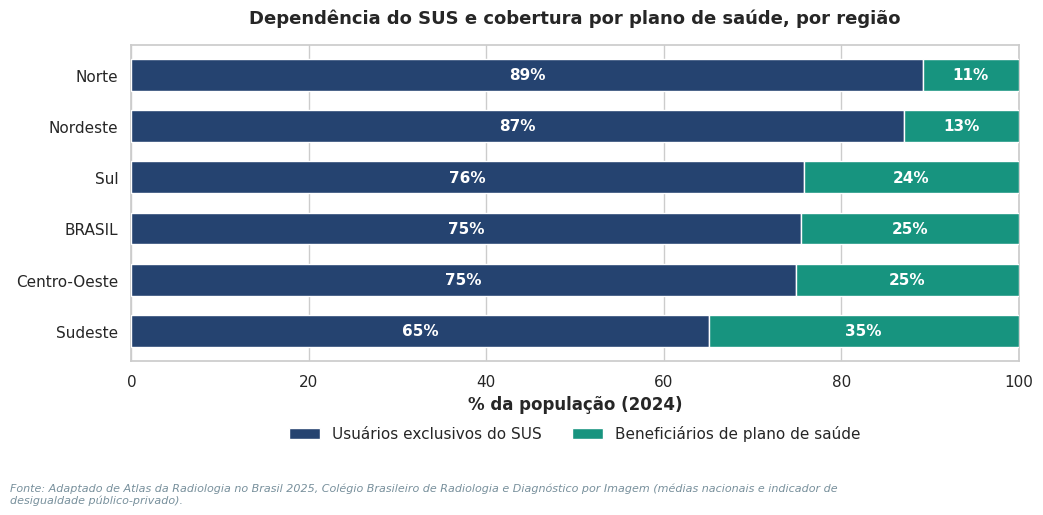

Paraíba (Nordeste): população 4.145.040 · SUS 3.680.381 (89%) · plano 464.659 (11%)


In [3]:
g = reg.assign(pct_sus=reg['SUS'] / reg['Pop'] * 100,
               pct_plano=reg['Plano'] / reg['Pop'] * 100).sort_values('pct_sus', ascending=False)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
y = np.arange(len(g))
ax.barh(y, g['pct_sus'], color=COR_SUS, height=0.62, label='Usuários exclusivos do SUS', zorder=3)
ax.barh(y, g['pct_plano'], left=g['pct_sus'], color=COR_PRIVADO, height=0.62,
        label='Beneficiários de plano de saúde', zorder=3)
for i, (s, p) in enumerate(zip(g['pct_sus'], g['pct_plano'])):
    ax.text(s / 2, i, f'{s:.0f}%', ha='center', va='center', color='white', fontweight='bold')
    ax.text(s + p / 2, i, f'{p:.0f}%', ha='center', va='center', color='white', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(g.index)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('% da população (2024)', fontweight='bold')
ax.set_title('Dependência do SUS e cobertura por plano de saúde, por região',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', visible=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)
fonte('Adaptado de Atlas da Radiologia no Brasil 2025, Colégio Brasileiro de Radiologia e Diagnóstico por Imagem '
      '(médias nacionais e indicador de desigualdade público-privado).')
finalizar('01_populacao_sus_plano')


def consulta_uf(nome):
    # Consulta rápida: consulta_uf('Paraíba')
    r = uf[uf['UF'].str.lower() == nome.lower()].iloc[0]
    print(f"{r['UF']} ({r['Região']}): população {br(r['Pop'])} · SUS {br(r['SUS'])} ({r['SUS']/r['Pop']:.0%}) · "
          f"plano {br(r['Plano'])} ({r['Plano']/r['Pop']:.0%})")


consulta_uf('Paraíba')

**Leitura.** O Norte (89%) e o Nordeste (87%) dependem quase integralmente do SUS. No Sudeste a parcela cai para 65%, e a região concentra 30,9 milhões dos 52,2 milhões de beneficiários de planos (59%). Sudeste e Sul juntos concentram 74% dos beneficiários.

## 2. Parque tecnológico de imagem

Exames de imagem (ressonância, tomografia, mamografia, ultrassom) são a matéria-prima dos modelos de visão computacional. Sem o equipamento físico não há imagem para treinar o algoritmo.

### 2.1 Densidade de equipamentos por 100 mil habitantes

**Fonte:** estimativas de referência CNES/DATASUS · *Atlas da Radiologia no Brasil 2025*, CBR (médias nacionais e indicador de desigualdade público-privado). Os valores são **estimativas de referência**, não dado oficial do CNES.

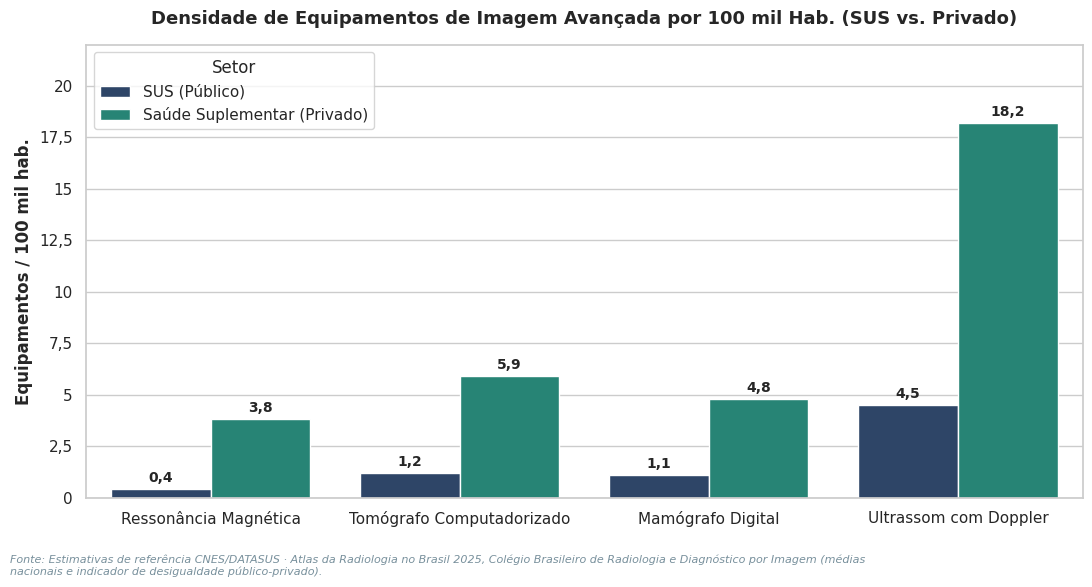

,Privado ÷ SUS (vezes)
Equipamento,
Ressonância Magnética,9.5
Tomógrafo Computadorizado,4.9
Mamógrafo Digital,4.4
Ultrassom com Doppler,4.0


In [4]:
dados_equip = pd.DataFrame({
    'Equipamento': ['Ressonância Magnética', 'Tomógrafo Computadorizado', 'Mamógrafo Digital', 'Ultrassom com Doppler'],
    'SUS (Público)': [0.4, 1.2, 1.1, 4.5],
    'Saúde Suplementar (Privado)': [3.8, 5.9, 4.8, 18.2]
})
df_equip = dados_equip.melt(id_vars='Equipamento', var_name='Setor', value_name='Por_100k')

plt.figure(figsize=(11, 5.5))
ax1 = sns.barplot(data=df_equip, x='Equipamento', y='Por_100k', hue='Setor', palette=[COR_SUS, COR_PRIVADO])
plt.title('Densidade de Equipamentos de Imagem Avançada por 100 mil Hab. (SUS vs. Privado)',
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Equipamentos / 100 mil hab.', fontweight='bold')
plt.xlabel('')
plt.ylim(0, 22)
eixo_pt(ax1.yaxis)
plt.legend(title='Setor', loc='upper left')
anotar_barras_v(ax1, casas=1)
fonte('Estimativas de referência CNES/DATASUS · Atlas da Radiologia no Brasil 2025, Colégio Brasileiro de Radiologia e '
      'Diagnóstico por Imagem (médias nacionais e indicador de desigualdade público-privado).')
finalizar('02a_densidade_equipamentos')

razao = dados_equip.set_index('Equipamento')
display((razao['Saúde Suplementar (Privado)'] / razao['SUS (Público)']).round(1).rename('Privado ÷ SUS (vezes)').to_frame())

**Leitura.** A maior distância está na ressonância magnética (9,5×). Nos demais equipamentos, a razão entre privado e SUS fica entre 4,0× e 4,9×.

### 2.2 Estudo de caso: mamógrafos no Acre

Reportagem da ContilNet (28/09/2025), *"Acre registra acesso limitado a exames de imagem e equipamentos de saúde"*: o estado tem **7 mamógrafos disponíveis para toda a rede SUS**.

**Fonte:** estimativas de referência CNES/DATASUS · *Atlas da Radiologia no Brasil 2025*, CBR; ContilNet.

7 mamógrafos ÷ 835.411 usuários do SUS = 0,84 por 100 mil (confere com 0,84)
A densidade privada de 35,38 por 100 mil implica ≈ 16 mamógrafos para 45.220 beneficiários


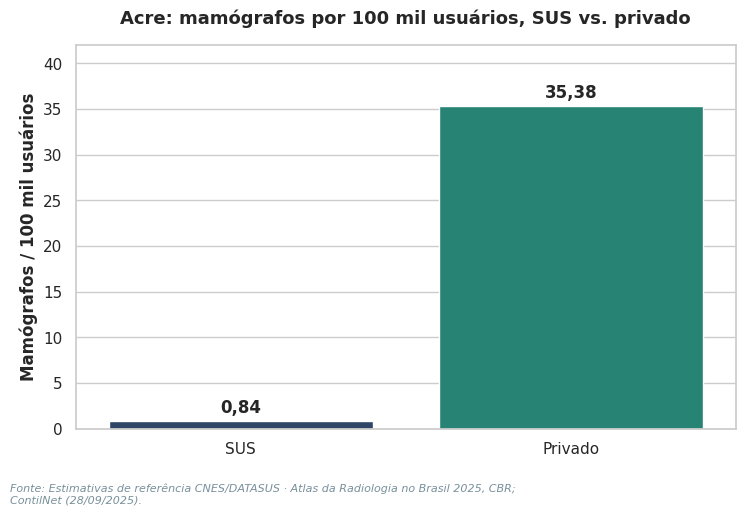

Razão privado ÷ SUS no Acre: 42.1×


In [5]:
acre = pd.DataFrame({'Setor': ['SUS', 'Privado'], 'Densidade': [0.84, 35.38]})

# Conferência: 7 mamógrafos na rede SUS ÷ usuários do SUS no Acre (tabela da seção 1)
sus_acre = uf.loc[uf['UF'] == 'Acre', 'SUS'].iloc[0]
plano_acre = uf.loc[uf['UF'] == 'Acre', 'Plano'].iloc[0]
assert round(7 / sus_acre * 1e5, 2) == 0.84
print(f'7 mamógrafos ÷ {br(sus_acre)} usuários do SUS = {num_pt(7 / sus_acre * 1e5, 2)} por 100 mil (confere com 0,84)')
print(f'A densidade privada de 35,38 por 100 mil implica ≈ {35.38 * plano_acre / 1e5:.0f} mamógrafos '
      f'para {br(plano_acre)} beneficiários')

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax = sns.barplot(data=acre, x='Setor', y='Densidade', hue='Setor', palette=[COR_SUS, COR_PRIVADO], legend=False, ax=ax)
ax.set_title('Acre: mamógrafos por 100 mil usuários, SUS vs. privado', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Mamógrafos / 100 mil usuários', fontweight='bold')
ax.set_xlabel('')
ax.set_ylim(0, 42)
eixo_pt(ax.yaxis)
anotar_barras_v(ax, casas=2, tam=12)
fonte('Estimativas de referência CNES/DATASUS · Atlas da Radiologia no Brasil 2025, CBR; '
      'ContilNet (28/09/2025).', largura=95)
finalizar('02b_acre_mamografos')

print(f'Razão privado ÷ SUS no Acre: {35.38 / 0.84:.1f}×')

### 2.3 Indicador de Desigualdade Público-Privado (IDPP)

O IDPP compara o acesso a exames entre beneficiários de plano e usuários exclusivos do SUS. Em 2023, o **IDPP geral de exames de imagem foi de 2,08**: beneficiários de plano têm mais que o dobro de acesso a exames de diagnóstico por imagem.

**Fonte:** *Atlas da Radiologia no Brasil 2025*, CBR.

> O IDPP e a razão de densidade da seção 2.1 são indicadores diferentes, com bases diferentes, e não devem ser comparados entre si (ver seção 11).

## 3. Conectividade

Muitas soluções de IA rodam em nuvem e exigem internet rápida, prontuário eletrônico e sistemas capazes de trocar dados. Esta seção compara a infraestrutura digital dos estabelecimentos públicos e privados.

**Fonte:** TIC Saúde 2025, Cetic.br/NIC.br. Pesquisa com 3.270 gestores de estabelecimentos de saúde, fev.–nov. 2025.

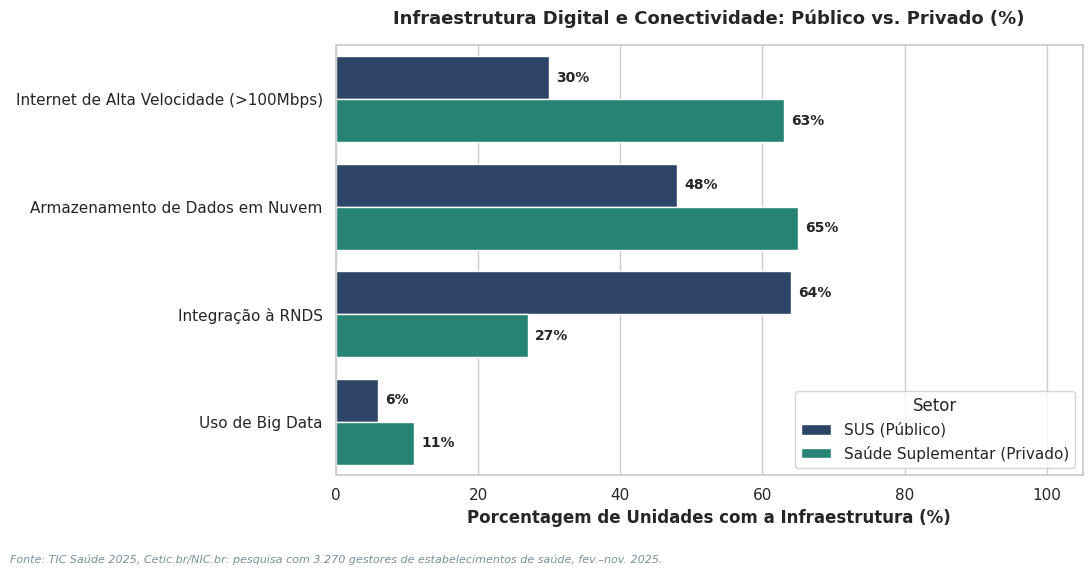

,SUS (Público),Saúde Suplementar (Privado),Diferença (p.p.),Razão privado ÷ SUS
Indicador,,,,
Internet de Alta Velocidade (>100Mbps),30.0,63.0,33.0,2.1
Armazenamento de Dados em Nuvem,48.0,65.0,17.0,1.4
Integração à RNDS,64.0,27.0,-37.0,0.4
Uso de Big Data,6.0,11.0,5.0,1.8


In [6]:
dados_infra = pd.DataFrame({
    'Indicador': ['Internet de Alta Velocidade (>100Mbps)', 'Armazenamento de Dados em Nuvem',
                  'Integração à RNDS', 'Uso de Big Data'],
    'SUS (Público)': [30.0, 48.0, 64.0, 6.0],
    'Saúde Suplementar (Privado)': [63.0, 65.0, 27.0, 11.0]
})
df_infra = dados_infra.melt(id_vars='Indicador', var_name='Setor', value_name='Porcentagem')

plt.figure(figsize=(11, 5.5))
ax2 = sns.barplot(data=df_infra, y='Indicador', x='Porcentagem', hue='Setor', palette=[COR_SUS, COR_PRIVADO])
plt.title('Infraestrutura Digital e Conectividade: Público vs. Privado (%)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Porcentagem de Unidades com a Infraestrutura (%)', fontweight='bold')
plt.ylabel('')
plt.xlim(0, 105)
plt.legend(title='Setor', loc='lower right')
anotar_barras_h(ax2, casas=0, sufixo='%')
fonte('TIC Saúde 2025, Cetic.br/NIC.br: pesquisa com 3.270 gestores de estabelecimentos de saúde, fev.–nov. 2025.')
finalizar('03_conectividade')

infra = dados_infra.set_index('Indicador').copy()
infra['Diferença (p.p.)'] = infra['Saúde Suplementar (Privado)'] - infra['SUS (Público)']
infra['Razão privado ÷ SUS'] = (infra['Saúde Suplementar (Privado)'] / infra['SUS (Público)']).round(1)
display(infra)

**Leitura.** O privado lidera em internet acima de 100 Mbps (63% × 30%) e em armazenamento em nuvem (65% × 48%). O quadro se inverte na integração à Rede Nacional de Dados em Saúde (RNDS): 64% dos estabelecimentos públicos contra 27% dos privados. Os dois lados têm gargalos, mas de natureza diferente. O uso de big data é baixo nos dois (6% e 11%).

## 4. Uso efetivo de IA

Esta seção mostra o que está de fato em uso, e não apenas o que é possível.

### 4.1 Adoção de IA por esfera administrativa

**Fonte:** TIC Saúde 2025, Cetic.br/NIC.br/CGI.br. Divulgação oficial de 12/05/2026 (Agência Brasil, InfoMoney).

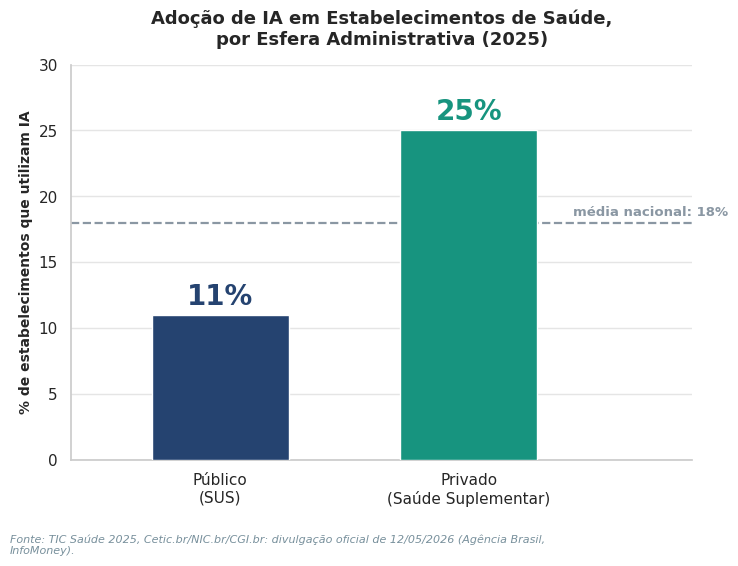

In [7]:
COR_MEDIA = '#8a97a3'

adocao_ia = pd.Series({'Público\n(SUS)': 11, 'Privado\n(Saúde Suplementar)': 25})
MEDIA_NACIONAL_IA = 18

fig, ax = plt.subplots(figsize=(7.5, 5.3))
bars = ax.bar(adocao_ia.index, adocao_ia.values, color=[COR_SUS, COR_PRIVADO], width=0.55, zorder=3)

ax.axhline(MEDIA_NACIONAL_IA, color=COR_MEDIA, linestyle='--', linewidth=1.6, zorder=2)
ax.text(1.42, MEDIA_NACIONAL_IA + 0.3, f'média nacional: {MEDIA_NACIONAL_IA}%',
        color=COR_MEDIA, fontsize=9.5, fontweight='bold', va='bottom')

for bar, val in zip(bars, adocao_ia.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.8, f'{val}%', ha='center',
            fontsize=20, fontweight='bold', color=bar.get_facecolor())

ax.set_ylim(0, 30)
ax.set_xlim(-0.6, 1.9)
ax.set_ylabel('% de estabelecimentos que utilizam IA', fontweight='bold', fontsize=10)
ax.set_title('Adoção de IA em Estabelecimentos de Saúde,\npor Esfera Administrativa (2025)',
             fontsize=13, fontweight='bold', pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#E5E5E5', zorder=0)
ax.grid(axis='x', visible=False)
fonte('TIC Saúde 2025, Cetic.br/NIC.br/CGI.br: divulgação oficial de 12/05/2026 (Agência Brasil, InfoMoney).', largura=100)
finalizar('04a_adocao_ia_esfera')

### 4.2 Tecnologias de IA utilizadas

A base deste gráfico são os estabelecimentos **que já usam alguma IA**. As três séries são **tipos de estabelecimento** (Total, Com internação até 50 leitos, SADT), e não SUS × privado. O gráfico mostra *quais* tecnologias são usadas.

**Fonte:** TIC Saúde 2025, Cetic.br/NIC.br, Gráfico 13, p. 80 (base: estabelecimentos que já utilizam alguma tecnologia de IA).

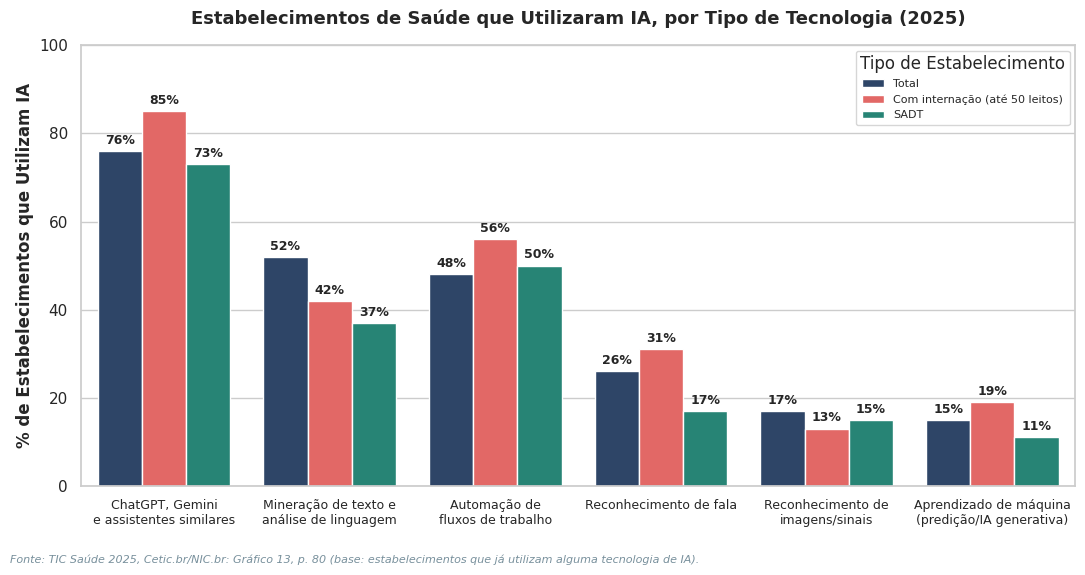

In [8]:
dados_ia = pd.DataFrame({
    'Tecnologia': ['ChatGPT, Gemini\ne assistentes similares', 'Mineração de texto e\nanálise de linguagem',
                   'Automação de\nfluxos de trabalho', 'Reconhecimento de fala',
                   'Reconhecimento de\nimagens/sinais', 'Aprendizado de máquina\n(predição/IA generativa)'],
    'Total': [76.0, 52.0, 48.0, 26.0, 17.0, 15.0],
    'Com internação (até 50 leitos)': [85.0, 42.0, 56.0, 31.0, 13.0, 19.0],
    'SADT': [73.0, 37.0, 50.0, 17.0, 15.0, 11.0],
})
df_ia = dados_ia.melt(id_vars='Tecnologia', var_name='Tipo de Estabelecimento', value_name='Pct')

plt.figure(figsize=(11, 5.5))
ax3 = sns.barplot(data=df_ia, x='Tecnologia', y='Pct', hue='Tipo de Estabelecimento',
                  palette=[COR_SUS, COR_TERCEIRA, COR_PRIVADO])
plt.title('Estabelecimentos de Saúde que Utilizaram IA, por Tipo de Tecnologia (2025)',
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel('% de Estabelecimentos que Utilizam IA', fontweight='bold')
plt.xlabel('')
plt.ylim(0, 100)
plt.legend(title='Tipo de Estabelecimento', loc='upper right', fontsize=8)
anotar_barras_v(ax3, casas=0, sufixo='%', tam=9)
plt.xticks(rotation=0, ha='center', fontsize=9)
fonte('TIC Saúde 2025, Cetic.br/NIC.br: Gráfico 13, p. 80 (base: estabelecimentos que já utilizam alguma tecnologia de IA).')
finalizar('04b_tecnologias_ia')

**Leitura.** A adoção de IA é de 11% nos estabelecimentos públicos e 25% nos privados, contra 18% na média nacional. Entre quem já usa IA, o uso predominante é de assistentes de linguagem (76% no total). Reconhecimento de imagens e sinais (17%) e aprendizado de máquina (15%), usos mais próximos do apoio ao diagnóstico, são os menos frequentes. O uso atual é mais de automação de processos do que de apoio clínico.

Isso sugere um ciclo de reforço: quem tem mais infraestrutura e dado adota IA mais cedo, e cada uso gera mais dado para a próxima geração de algoritmos.

## 5. Iniciativas de IA no SUS

Registro qualitativo, sem série numérica associada.

| Iniciativa | Detalhes | Fonte |
|---|---|---|
| Primeira UTI inteligente do SUS, no Rio de Janeiro | Lançada no Hospital Universitário Clementino Fraga Filho. Investimento de mais de R$ 180 milhões. O projeto prevê IA para monitorar pacientes, prever riscos e integrar informações diretamente aos prontuários eletrônicos. | g1 Rio, 27/06/2026 |
| Vídeo sobre a UTI inteligente | Reportagem em vídeo (3 min 29 s). | YouTube, Rede CNT Brasil (set. 2026) |

## 6. Saúde suplementar: pesquisa Anahp

Levantamento da Anahp (Associação Nacional de Hospitais Privados) em parceria com a Wolters Kluwer, sobre o uso de ferramentas de suporte à decisão clínica.

**Fonte:** *Pesquisa sobre qualidade, segurança do paciente e a importância das ferramentas de suporte à decisão clínica.* Anahp, em parceria com Wolters Kluwer (2025).

### 6.1 A instituição disponibiliza algum recurso de IA?

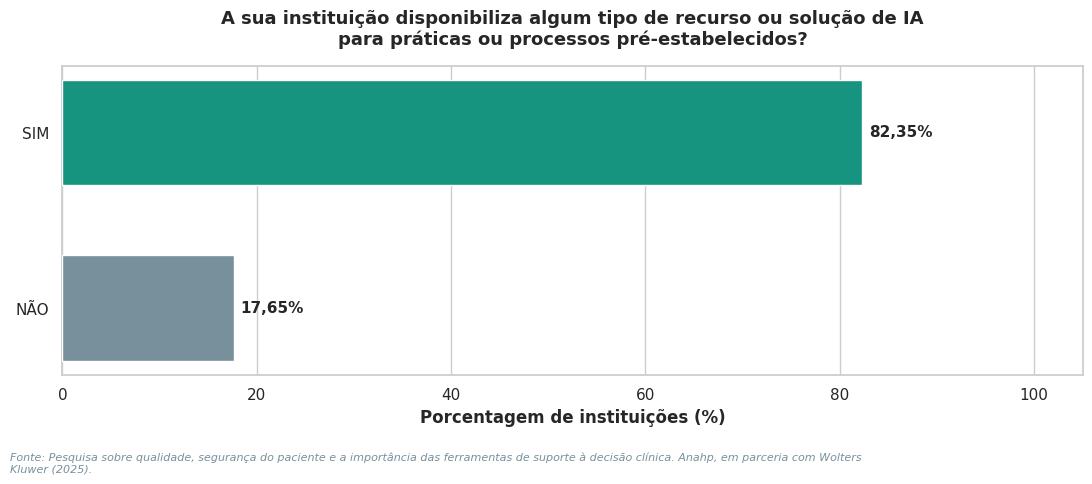

In [9]:
anahp_sim_nao = pd.DataFrame({'Resposta': ['SIM', 'NÃO'], 'Pct': [82.35, 17.65]})

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(anahp_sim_nao['Resposta'], anahp_sim_nao['Pct'], color=[COR_PRIVADO, COR_CINZA], height=0.6, zorder=3)
ax.invert_yaxis()
ax.set_xlim(0, 105)
ax.grid(axis='y', visible=False)
ax.set_xlabel('Porcentagem de instituições (%)', fontweight='bold')
ax.set_title('A sua instituição disponibiliza algum tipo de recurso ou solução de IA\n'
             'para práticas ou processos pré-estabelecidos?', fontsize=13, fontweight='bold', pad=15)
anotar_barras_h(ax, casas=2, sufixo='%', tam=11)
fonte('Pesquisa sobre qualidade, segurança do paciente e a importância das ferramentas de suporte à decisão clínica. '
      'Anahp, em parceria com Wolters Kluwer (2025).')
finalizar('06a_anahp_disponibiliza_ia')

### 6.2 Como os recursos de IA são utilizados

Pergunta de **múltipla escolha** ("escolha, ao menos, uma opção"): cada barra é a parcela de instituições que marcou aquela opção, e a soma passa de 100%.

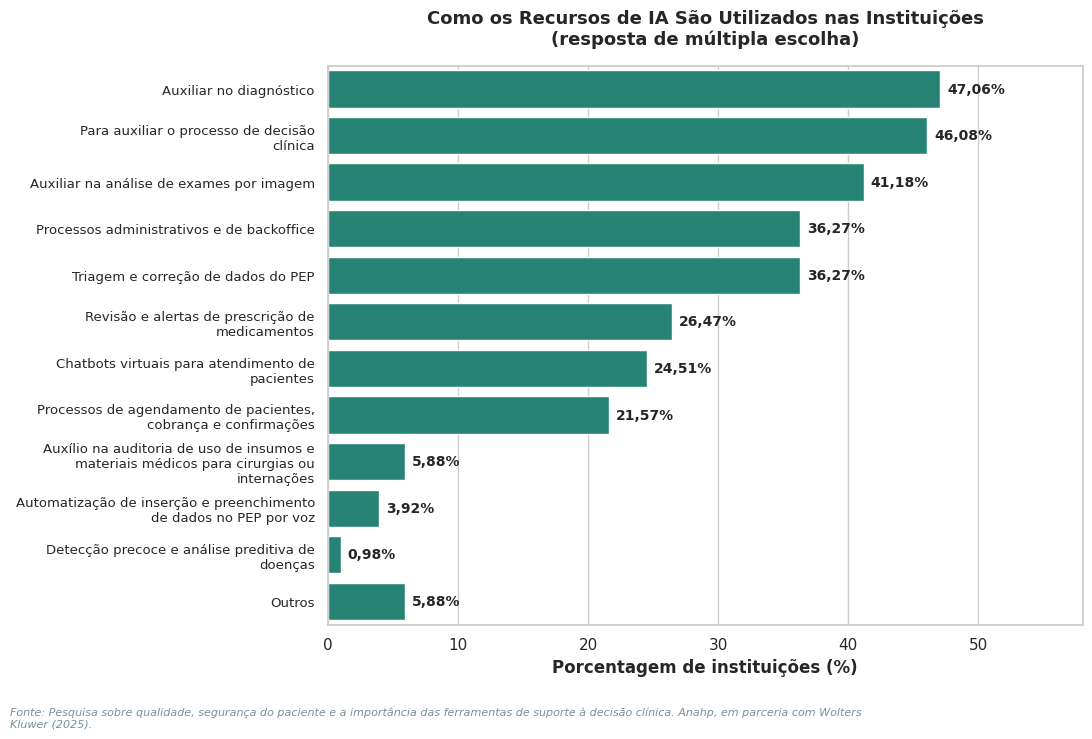

In [10]:
dados_uso = pd.DataFrame({
    'Uso': [
        'Auxiliar no diagnóstico',
        'Para auxiliar o processo de decisão clínica',
        'Auxiliar na análise de exames por imagem',
        'Processos administrativos e de backoffice',
        'Triagem e correção de dados do PEP',
        'Revisão e alertas de prescrição de medicamentos',
        'Chatbots virtuais para atendimento de pacientes',
        'Processos de agendamento de pacientes, cobrança e confirmações',
        'Auxílio na auditoria de uso de insumos e materiais médicos para cirurgias ou internações',
        'Automatização de inserção e preenchimento de dados no PEP por voz',
        'Detecção precoce e análise preditiva de doenças',
        'Outros',
    ],
    'Pct': [47.06, 46.08, 41.18, 36.27, 36.27, 26.47, 24.51, 21.57, 5.88, 3.92, 0.98, 5.88]
})
dados_uso['Rótulo'] = dados_uso['Uso'].apply(lambda t: textwrap.fill(t, 42))

plt.figure(figsize=(11, 7))
ax7 = sns.barplot(data=dados_uso, y='Rótulo', x='Pct', color=COR_PRIVADO)
plt.title('Como os Recursos de IA São Utilizados nas Instituições\n(resposta de múltipla escolha)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Porcentagem de instituições (%)', fontweight='bold')
plt.ylabel('')
plt.xlim(0, 58)
plt.yticks(fontsize=9.5)
anotar_barras_h(ax7, casas=2, sufixo='%')
fonte('Pesquisa sobre qualidade, segurança do paciente e a importância das ferramentas de suporte à decisão clínica. '
      'Anahp, em parceria com Wolters Kluwer (2025).')
finalizar('06b_anahp_usos_ia')

**Leitura.** Na amostra da Anahp, 82,35% das instituições disponibilizam algum recurso de IA. Os usos mais citados são clínicos: auxílio ao diagnóstico (47,06%), ao processo de decisão clínica (46,08%) e à análise de exames por imagem (41,18%). Detecção precoce e análise preditiva de doenças aparece em apenas 0,98%.

### 6.3 Qual é o tamanho da amostra?

A publicação da pesquisa, tal como usada aqui, não informa o número de respondentes. Como todos os percentuais têm duas casas decimais, é possível procurar quais tamanhos de amostra os reproduzem exatamente.

In [11]:
pcts = dados_uso['Pct'].tolist() + anahp_sim_nao['Pct'].tolist()

def n_compativeis(pcts, n_max=400):
    # Tamanhos de amostra n para os quais todo percentual p é igual a round(k/n*100, 2) para algum k inteiro.
    return [n for n in range(1, n_max + 1)
            if all(any(abs(round(k / n * 100, 2) - p) < 1e-9 for k in range(n + 1)) for p in pcts)]

candidatos = n_compativeis(pcts)
N_INFERIDO = candidatos[0]
print('Tamanhos de amostra compatíveis:', candidatos)

dados_uso['Nº de instituições (inferido)'] = (dados_uso['Pct'] / 100 * N_INFERIDO).round().astype(int)
print(f"\nMenor n compatível: {N_INFERIDO}  →  'SIM' = {round(0.8235 * N_INFERIDO)} instituições, "
      f"'NÃO' = {round(0.1765 * N_INFERIDO)}")
display(dados_uso[['Uso', 'Pct', 'Nº de instituições (inferido)']])

Tamanhos de amostra compatíveis: [102, 204, 306]

Menor n compatível: 102  →  'SIM' = 84 instituições, 'NÃO' = 18


,Uso,Pct,Nº de instituições (inferido)
0,Auxiliar no diagnóstico,47.06,48
1,Para auxiliar o processo de decisão clínica,46.08,47
2,Auxiliar na análise de exames por imagem,41.18,42
3,Processos administrativos e de backoffice,36.27,37
4,Triagem e correção de dados do PEP,36.27,37
5,Revisão e alertas de prescrição de medicamentos,26.47,27
6,Chatbots virtuais para atendimento de pacientes,24.51,25
7,"Processos de agendamento de pacientes, cobranç...",21.57,22
8,Auxílio na auditoria de uso de insumos e mater...,5.88,6
9,Automatização de inserção e preenchimento de d...,3.92,4


Os percentuais são compatíveis com **n = 102** instituições (os demais tamanhos compatíveis são múltiplos de 102). 
Isso significa que 0,98% de detecção preditiva corresponde a uma única instituição, e todos os percentuais têm como base o total de respondentes, não apenas quem tem IA.

### 6.4 Por que 82,35% e 18% não se contradizem

| | TIC Saúde 2025 | Pesquisa Anahp |
|---|---|---|
| Quem responde | 3.270 gestores de estabelecimentos de todos os tipos e esferas | Instituições associadas à Anahp (hospitais privados; n ≈ 102, inferido) |
| Pergunta | O estabelecimento **utiliza** tecnologias de IA? | A instituição **disponibiliza** algum recurso de IA para processos pré-estabelecidos? |
| Resultado | 18% (média); 11% público; 25% privado | 82,35% |

São populações e perguntas diferentes, e os números não são comparáveis diretamente. O 82,35% descreve hospitais privados de referência, e não o Brasil. Lido junto com o TIC Saúde, porém, é coerente com o gradiente descrito na seção 4: a adoção cresce com o porte e o perfil privado do estabelecimento.

## 7. A dupla desigualdade: setorial e regional

A desigualdade não é só entre SUS e plano de saúde, é também geográfica. Leitos de UTI importam para a IA porque ambientes de alta complexidade geram dados ricos e contínuos do paciente (sinais vitais em tempo real, séries temporais).

**Fonte:** estimativa ilustrativa baseada em padrões de distribuição regional CNES/DATASUS. Os valores **não são dado oficial**.

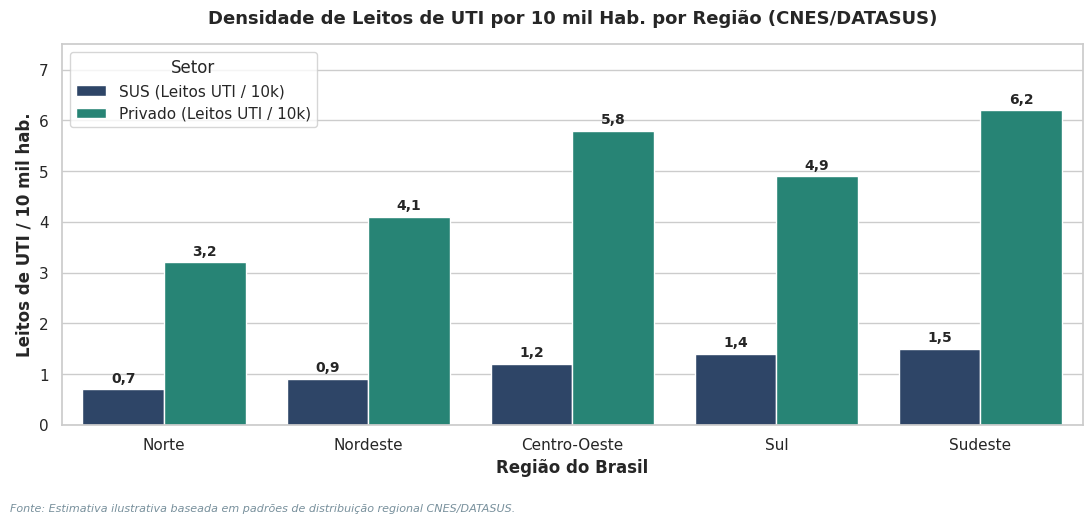

,SUS (Leitos UTI / 10k),Privado (Leitos UTI / 10k),Razão privado ÷ SUS
Região,,,
Norte,0.7,3.2,4.6
Nordeste,0.9,4.1,4.6
Centro-Oeste,1.2,5.8,4.8
Sul,1.4,4.9,3.5
Sudeste,1.5,6.2,4.1


Melhor combinação (privado, Sudeste): 6,2 · pior (SUS, Norte): 0,7 · razão ≈ 8,9×


In [12]:
dados_uti = pd.DataFrame({
    'Região': ['Norte', 'Nordeste', 'Centro-Oeste', 'Sul', 'Sudeste'],
    'SUS (Leitos UTI / 10k)': [0.7, 0.9, 1.2, 1.4, 1.5],
    'Privado (Leitos UTI / 10k)': [3.2, 4.1, 5.8, 4.9, 6.2]
})
df_uti = dados_uti.melt(id_vars='Região', var_name='Setor', value_name='Leitos_10k')

plt.figure(figsize=(11, 5))
ax4 = sns.barplot(data=df_uti, x='Região', y='Leitos_10k', hue='Setor', palette=[COR_SUS, COR_PRIVADO])
plt.title('Densidade de Leitos de UTI por 10 mil Hab. por Região (CNES/DATASUS)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Leitos de UTI / 10 mil hab.', fontweight='bold')
plt.xlabel('Região do Brasil', fontweight='bold')
plt.ylim(0, 7.5)
eixo_pt(ax4.yaxis)
plt.legend(title='Setor', loc='upper left')
anotar_barras_v(ax4, casas=1)
fonte('Estimativa ilustrativa baseada em padrões de distribuição regional CNES/DATASUS.')
finalizar('07_uti_regiao')

uti = dados_uti.set_index('Região').copy()
uti['Razão privado ÷ SUS'] = (uti['Privado (Leitos UTI / 10k)'] / uti['SUS (Leitos UTI / 10k)']).round(1)
display(uti)

melhor = dados_uti['Privado (Leitos UTI / 10k)'].max()   # privado, Sudeste
pior = dados_uti['SUS (Leitos UTI / 10k)'].min()         # SUS, Norte
print(f'Melhor combinação (privado, Sudeste): {num_pt(melhor)} · pior (SUS, Norte): {num_pt(pior)} '
      f'· razão ≈ {num_pt(melhor / pior)}×')

**Leitura.** Em cada região, o privado tem entre 3,5× (Sul) e 4,8× (Centro-Oeste) mais leitos de UTI por habitante que o SUS. Dentro do próprio SUS, o Sudeste (1,5) tem cerca de 2,1× a densidade do Norte (0,7). Somando as duas camadas, a distância entre a melhor e a pior combinação (privado no Sudeste × SUS no Norte) é de aproximadamente 8,9×.

## 8. Por que a distância persiste

| Eixo | Fator |
|---|---|
| Burocracia | Falta de planejamento estratégico de investimento em TI |
| Formação | Limitações de estrutura e de profissionais capacitados |
| Resultado | Implementação fragmentada |

Reduzir essa desigualdade não é só uma questão de justiça social, é também de qualidade técnica: um algoritmo treinado com dados mais representativos é mais seguro para todos.

## 9. Síntese: descompasso estrutural de dados

**Índice de concentração no setor privado** = (participação do privado no recurso) ÷ (participação do privado na população, 25%).

- 1,0× significa recurso distribuído proporcionalmente à população (equidade).
- Acima de 1,0× indica concentração no privado acima do esperado.

**Fontes:** população com plano de saúde, 25% (ANS/IBGE); exames de ressonância 2023 e parque de imagem (*Atlas da Radiologia no Brasil 2025*, CBR); leitos de UTI adulto nacionais, 2025: 24.426 no setor privado de 47.644 totais (AMIB, *"País expande UTIs..."*, 2026).

O índice é uma **síntese própria** do grupo, calculada abaixo a partir dos dados de base.

In [13]:
COTA_PLANO = 0.25   # população com plano de saúde (ANS/IBGE, arredondada)

# Exames de ressonância realizados em 2023 (Atlas 2025, CBR)
exames_priv, exames_sus = 9_292_425, 2_213_807
# Leitos de UTI adulto, 2025 (AMIB, 2026)
uti_priv, uti_total = 24_426, 47_644
# Participação do privado no parque de imagem avançada (Atlas 2025, CBR, conforme usado nos slides; ver seção 11)
parque_priv = 0.784

participacao = pd.Series({
    'Exames de ressonância realizados (2023)': exames_priv / (exames_priv + exames_sus),
    'Parque de imagem avançada (equipamentos instalados)': parque_priv,
    'Leitos de UTI (total nacional, 2025)': uti_priv / uti_total,
})
indice = (participacao / COTA_PLANO).round(1)
assert list(indice) == [3.2, 3.1, 2.1]

display(pd.DataFrame({'Participação do privado (%)': (participacao * 100).round(1),
                      'Índice de concentração (×)': indice}))

,Participação do privado (%),Índice de concentração (×)
Exames de ressonância realizados (2023),80.8,3.2
Parque de imagem avançada (equipamentos instalados),78.4,3.1
"Leitos de UTI (total nacional, 2025)",51.3,2.1


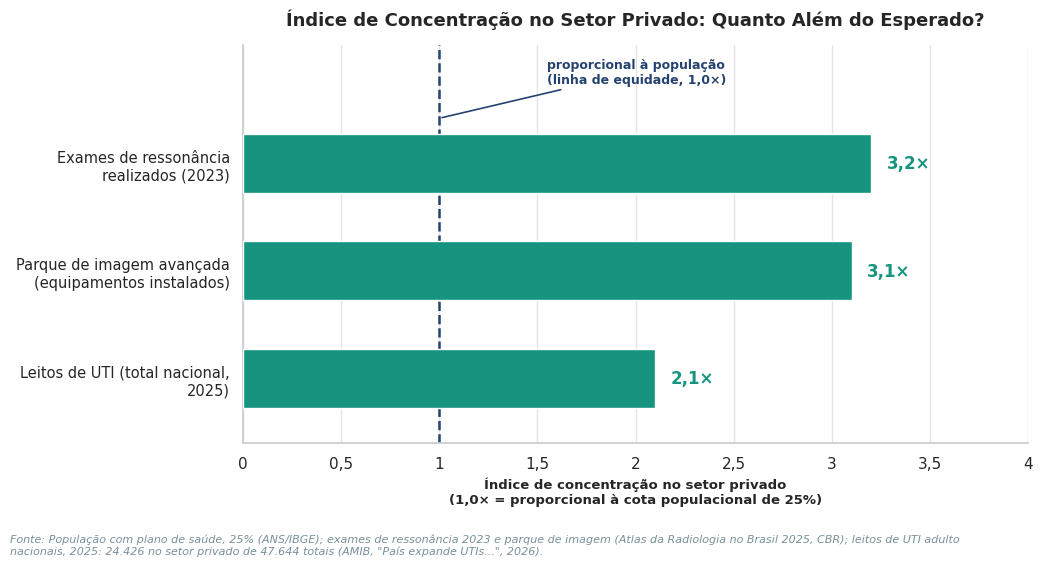

In [14]:
plot_df = indice.sort_values().rename(lambda s: textwrap.fill(s, 30))

fig, ax = plt.subplots(figsize=(10.5, 5.3))
y_pos = range(len(plot_df))
ax.barh(y_pos, plot_df.values, color=COR_PRIVADO, height=0.55, zorder=3)

ax.axvline(1.0, color=COR_SUS, linestyle='--', linewidth=1.8, zorder=2)
ax.annotate('proporcional à população\n(linha de equidade, 1,0×)',
            xy=(1.0, 2.42), xytext=(1.55, 2.75),
            fontsize=9, fontweight='bold', color=COR_SUS,
            arrowprops=dict(arrowstyle='-', color=COR_SUS, lw=1.2))

for i, v in enumerate(plot_df.values):
    ax.text(v + 0.08, i, f'{num_pt(v)}×', va='center', fontsize=12, fontweight='bold', color=COR_PRIVADO)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_df.index, fontsize=10.5)
ax.set_xlim(0, 4)
ax.set_ylim(-0.6, 3.1)
eixo_pt(ax.xaxis)
ax.set_xlabel('Índice de concentração no setor privado\n(1,0× = proporcional à cota populacional de 25%)',
              fontweight='bold', fontsize=9.5)
ax.set_title('Índice de Concentração no Setor Privado: Quanto Além do Esperado?',
             fontsize=13, fontweight='bold', pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', color='#E5E5E5', zorder=0)
ax.grid(axis='y', visible=False)
fonte('População com plano de saúde, 25% (ANS/IBGE); exames de ressonância 2023 e parque de imagem (Atlas da Radiologia '
      'no Brasil 2025, CBR); leitos de UTI adulto nacionais, 2025: 24.426 no setor privado de 47.644 totais '
      '(AMIB, "País expande UTIs...", 2026).', largura=170)
finalizar('09_indice_concentracao')

**Leitura.** Em todos os indicadores o setor privado detém mais do que sua cota populacional: de 2,1× nos leitos de UTI a 3,2× nos exames de ressonância. É o descompasso entre onde estão as pessoas e onde estão os dados que vão treinar os algoritmos.

## 10. Conclusões

Quatro gargalos resumem a análise de acesso e infraestrutura:

1. **Gargalo de equipamento.** A imagem avançada se concentra no setor privado, com até 9,5× mais densidade por habitante (ressonância).
2. **Gargalo de qualidade de conexão.** Apenas 30% dos estabelecimentos públicos têm internet acima de 100 Mbps, contra 63% dos privados.
3. **Uso efetivo concentrado.** A IA está em 18% dos estabelecimentos, com adoção de 11% no público e 25% no privado.
4. **A sombra dos dados.** Cerca de 75% da população depende do SUS, mas a infraestrutura geradora de dados está concentrada no privado: de 2,1× a 3,2× sua cota populacional.

O painel abaixo reúne os indicadores-chave a partir das tabelas construídas ao longo do notebook.

In [15]:
eq = dados_equip.set_index('Equipamento')
inf = dados_infra.set_index('Indicador')

painel = pd.DataFrame([
    ('Gargalo de equipamento', 'Ressonância magnética (por 100 mil hab.)',
     eq.loc['Ressonância Magnética', 'SUS (Público)'], eq.loc['Ressonância Magnética', 'Saúde Suplementar (Privado)']),
    ('Gargalo de qualidade de conexão', 'Internet > 100 Mbps (% dos estabelecimentos)',
     inf.loc['Internet de Alta Velocidade (>100Mbps)', 'SUS (Público)'],
     inf.loc['Internet de Alta Velocidade (>100Mbps)', 'Saúde Suplementar (Privado)']),
    ('Uso efetivo concentrado', 'Estabelecimentos que usam IA (%)',
     adocao_ia.iloc[0], adocao_ia.iloc[1]),
], columns=['Eixo', 'Indicador', 'SUS', 'Privado'])
painel['Razão privado ÷ SUS'] = (painel['Privado'] / painel['SUS']).round(1)
display(painel)

print('A sombra dos dados: índice de concentração no privado (1,0× = proporcional à população)')
display(indice.to_frame('Índice (×)'))

,Eixo,Indicador,SUS,Privado,Razão privado ÷ SUS
0,Gargalo de equipamento,Ressonância magnética (por 100 mil hab.),0.4,3.8,9.5
1,Gargalo de qualidade de conexão,Internet > 100 Mbps (% dos estabelecimentos),30.0,63.0,2.1
2,Uso efetivo concentrado,Estabelecimentos que usam IA (%),11.0,25.0,2.3


A sombra dos dados: índice de concentração no privado (1,0× = proporcional à população)


,Índice (×)
Exames de ressonância realizados (2023),3.2
Parque de imagem avançada (equipamentos instalados),3.1
"Leitos de UTI (total nacional, 2025)",2.1


## 11. Notas metodológicas e limitações

- **Estimativas.** A densidade de equipamentos (seção 2.1) e os leitos de UTI por região (seção 7) são estimativas de referência ou ilustrativas baseadas em padrões do CNES/DATASUS. Não devem ser citados como dado oficial.
- **Indicadores diferentes.** A razão de densidade por 100 mil habitantes (≈ 9,5× para ressonância) e o IDPP do Atlas (≈ 3× para ressonância) medem coisas distintas, com bases distintas.
- **Como ler o gráfico de tecnologias (seção 4.2).** As séries são tipos de estabelecimento, não SUS × privado, e a base são os estabelecimentos que já usam IA. O rótulo da série "Com internação (até 50 leitos)" deve ser conferido no Gráfico 13, p. 80, do relatório original.
- **Pesquisa Anahp.** A base é seletiva (hospitais privados associados) e não representa o país. O tamanho da amostra (n = 102) é inferido dos percentuais, não informado.
- **Cota populacional.** O índice da seção 9 usa a cota arredondada de 25%. Com a cota exata (≈ 24,5%), os valores mudariam ligeiramente (por exemplo, 3,1× → 3,2× no parque de imagem).
- **Participação do privado no parque de imagem (78,4%).** Este valor foi usado na síntese da seção 9, mas não é reproduzível a partir da densidade da seção 2.1. A verificação abaixo mostra o que os valores do Gráfico 1 implicariam.
- **Pendência.** Completar a referência exata do relatório ANS/IBGE que originou os dados de população por UF.

In [16]:
# Verificação de consistência: participação do privado implícita nas densidades da seção 2.1,
# assumindo densidade por usuário de cada setor e população 75% SUS / 25% plano.
p_sus, p_priv = 0.75, 0.25
d = dados_equip.set_index('Equipamento')
part_implicita = (p_priv * d['Saúde Suplementar (Privado)']) / (
    p_priv * d['Saúde Suplementar (Privado)'] + p_sus * d['SUS (Público)'])

display((part_implicita * 100).round(1).rename('Participação implícita do privado (%)').to_frame())
print(f'Intervalo implícito: {part_implicita.min():.1%} a {part_implicita.max():.1%}  ·  valor usado na seção 9: {parque_priv:.1%}')

,Participação implícita do privado (%)
Equipamento,
Ressonância Magnética,76.0
Tomógrafo Computadorizado,62.1
Mamógrafo Digital,59.3
Ultrassom com Doppler,57.4


Intervalo implícito: 57.4% a 76.0%  ·  valor usado na seção 9: 78.4%


## 12. Referências

- NÚCLEO DE INFORMAÇÃO E COORDENAÇÃO DO PONTO BR (NIC.br). *Pesquisa sobre o uso das tecnologias de informação e comunicação nos estabelecimentos de saúde brasileiros: TIC Saúde 2025.* São Paulo: Cetic.br/NIC.br, 2026. Divulgação oficial de 12/05/2026 (Agência Brasil, InfoMoney).
- COLÉGIO BRASILEIRO DE RADIOLOGIA E DIAGNÓSTICO POR IMAGEM (CBR). *Atlas da Radiologia no Brasil 2025.* São Paulo: CBR, 2025.
- CNES/DATASUS: estimativas de referência de equipamentos e padrões de distribuição regional de leitos.
- ANAHP; WOLTERS KLUWER. *Pesquisa sobre qualidade, segurança do paciente e a importância das ferramentas de suporte à decisão clínica.* 2025.
- AMIB. *"País expande UTIs..."*, 2026 (leitos de UTI adulto: 24.426 no setor privado de 47.644 totais).
- ANS; IBGE. População total, usuários do SUS e de planos por UF. *(Completar a referência do relatório.)*
- CONTILNET. *Acre registra acesso limitado a exames de imagem e equipamentos de saúde.* 28/09/2025.
- G1 RIO. *Ministério da Saúde inaugura 1ª UTI inteligente do SUS no Rio.* 27/06/2026.
- REDE CNT BRASIL. Reportagem em vídeo sobre a UTI inteligente do SUS. YouTube, set. 2026.